# Theoretical validation — Figure 3

Numerical convergence of the SeapoPym biomass to the analytical asymptote
$B_{eq} = E \cdot \mathrm{NPP} / \lambda(T)$ under constant forcing,
at four temperatures (0, 10, 20, 30 °C) with $\mathrm{NPP} = 300\,\mathrm{mg\,C\,m^{-2}\,d^{-1}}$.

Reference: Manuscript Section 2.4.1 and Appendix A.
Runtime: a few minutes.

Output: `figures/Figure_3.{pdf,png}`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
import yaml

from seapopym.configuration.no_transport import (
    ForcingParameter,
    ForcingUnit,
    FunctionalGroupParameter,
    FunctionalGroupUnit,
    FunctionalTypeParameter,
    KernelParameter,
    MigratoryTypeParameter,
    NoTransportConfiguration,
)
from seapopym.model.no_transport_model import NoTransportModel


def _project_root(marker: str = "pyproject.toml") -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Project root marker {marker!r} not found.")


PROJECT_ROOT = _project_root()
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

with open(PROJECT_ROOT / "parameters.yaml") as f:
    PARAMS = yaml.safe_load(f)

REF = PARAMS["model_parameters"]["reference"]
BENCH = PARAMS["theoretical_benchmark"]

## Analytical asymptote

Under constant $T$ and $\mathrm{NPP}$ and at steady state ($\partial B/\partial t = 0$),
Eq. A.1 of the manuscript reduces to $B_{eq} = R / \lambda(T)$
with $R = E \cdot \mathrm{NPP}$ and $\lambda(T) = \lambda_0 \exp(\gamma_\lambda T)$ (Eq. A.2).

The model applies an internal temperature transformation
$T_\mathrm{eff} = T / (1 + T/273)$ before evaluating $\lambda$; we use the same
transformation when computing the analytical reference.


In [2]:
def transform_temperature(T):
    return T / (1 + T / 273)


def mortality_rate(T):
    return REF["lambda_temperature_0"] * np.exp(REF["gamma_lambda_temperature"] * T)


def analytical_asymptote(T_celsius):
    return REF["energy_transfert"] * BENCH["npp_constant"] / mortality_rate(
        transform_temperature(T_celsius)
    )

## Constant forcing and simulation

A single-cell forcing dataset is constructed for each target temperature
(no spatial dimension is required for this 0-D benchmark).


In [3]:
DURATION_DAYS = 540  # ~18 months — long enough to reach steady state at 0 °C


def build_constant_forcing(T_celsius: float, duration_days: int = DURATION_DAYS) -> tuple[xr.DataArray, xr.DataArray]:
    time = pd.date_range("2000-01-01", periods=duration_days, freq="D")
    coord_attrs = {
        "time": {"axis": "T"},
        "latitude": {"axis": "Y"},
        "longitude": {"axis": "X"},
        "depth": {"axis": "Z"},
    }
    temperature = xr.DataArray(
        np.full((duration_days, 1, 1, 1), T_celsius, dtype=np.float32),
        dims=("time", "depth", "latitude", "longitude"),
        coords={"time": time, "depth": [1], "latitude": [0.5], "longitude": [0.5]},
        attrs={"units": "degC"},
    )
    npp = xr.DataArray(
        np.full((duration_days, 1, 1), BENCH["npp_constant"], dtype=np.float32),
        dims=("time", "latitude", "longitude"),
        coords={"time": time, "latitude": [0.5], "longitude": [0.5]},
        attrs={"units": "mg/m2/day"},
    )
    for da in (temperature, npp):
        for coord_name, attrs in coord_attrs.items():
            if coord_name in da.coords:
                da[coord_name].attrs.update(attrs)
    return temperature, npp


def run_benchmark(T_celsius: float) -> xr.DataArray:
    temperature, npp = build_constant_forcing(T_celsius)
    functional_group = FunctionalGroupParameter(
        functional_group=[
            FunctionalGroupUnit(
                name=f"{T_celsius}deg",
                energy_transfert=REF["energy_transfert"],
                functional_type=FunctionalTypeParameter(
                    lambda_temperature_0=REF["lambda_temperature_0"],
                    gamma_lambda_temperature=REF["gamma_lambda_temperature"],
                    tr_0=REF["tr_0"],
                    gamma_tr=REF["gamma_tr"],
                ),
                migratory_type=MigratoryTypeParameter(day_layer=1, night_layer=1),
            )
        ]
    )
    forcing = ForcingParameter(
        temperature=ForcingUnit(forcing=temperature),
        primary_production=ForcingUnit(forcing=npp),
    )
    config = NoTransportConfiguration(
        forcing=forcing,
        functional_group=functional_group,
        kernel=KernelParameter(
            compute_initial_conditions=False,
            compute_preproduction=False,
        ),
    )
    with NoTransportModel.from_configuration(configuration=config) as model:
        model.run()
        biomass = model.state.biomass.copy()
    return biomass.pint.quantify().pint.to("mg/m2").pint.dequantify()


biomass = {T: run_benchmark(T) for T in BENCH["temperatures_celsius"]}

None unit is milligram / day / meter ** 2, it will be converted to gram / day / meter ** 2.
None unit is milligram / day / meter ** 2, it will be converted to gram / day / meter ** 2.
None unit is milligram / day / meter ** 2, it will be converted to gram / day / meter ** 2.
None unit is milligram / day / meter ** 2, it will be converted to gram / day / meter ** 2.
None unit is milligram / day / meter ** 2, it will be converted to gram / day / meter ** 2.
None unit is milligram / day / meter ** 2, it will be converted to gram / day / meter ** 2.
None unit is milligram / day / meter ** 2, it will be converted to gram / day / meter ** 2.
None unit is milligram / day / meter ** 2, it will be converted to gram / day / meter ** 2.


## Figure 3 — modelled biomass vs. analytical asymptote


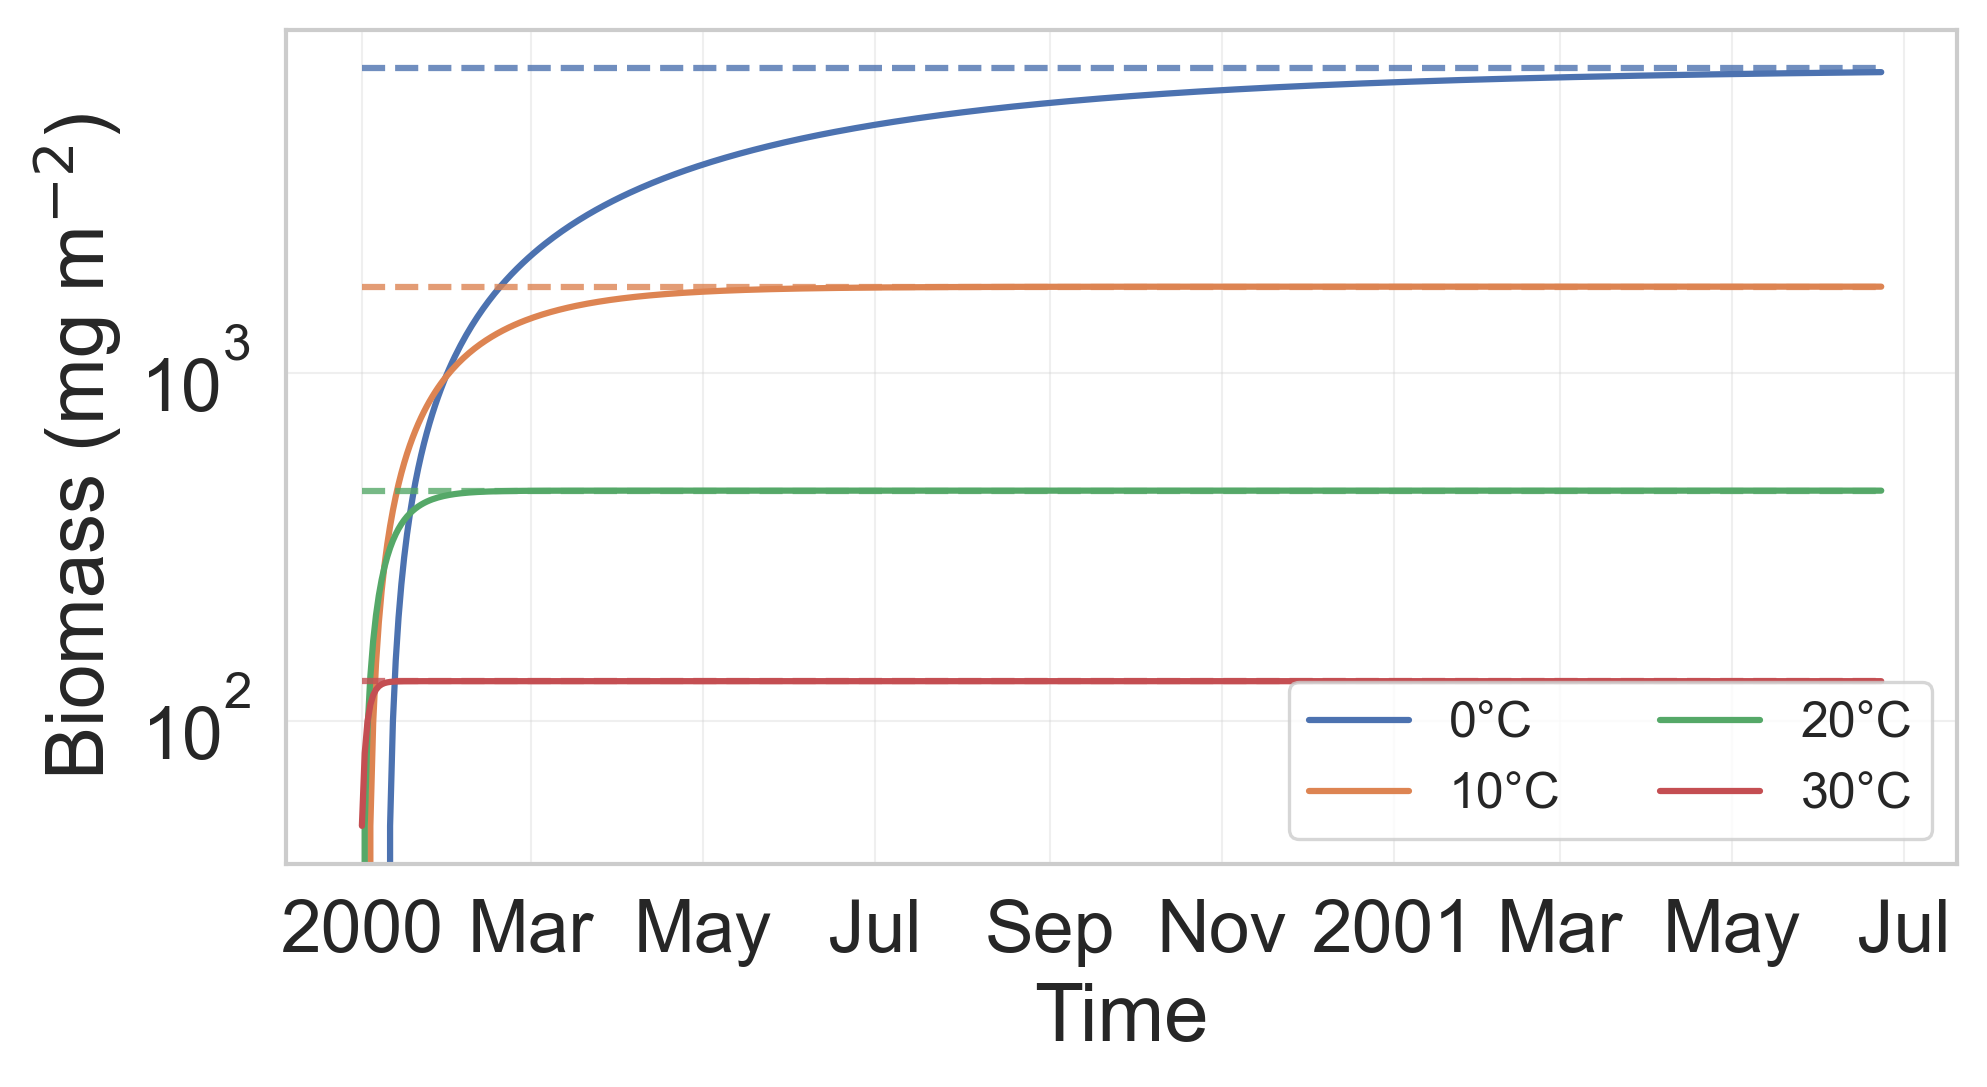

In [4]:
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=2)

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)
colors = sns.color_palette("deep", len(BENCH["temperatures_celsius"]))

for T, color in zip(BENCH["temperatures_celsius"], colors, strict=True):
    series = biomass[T].isel(X=0, Y=0).squeeze()
    series.plot(ax=ax, label=f"{T}°C", linewidth=1.5, color=color)
    xr.full_like(series, analytical_asymptote(T)).plot(
        ax=ax, linestyle="--", linewidth=1.5, color=color, alpha=0.8,
    )

ax.set_yscale("log")
ax.set_ylabel(r"Biomass (mg m$^{-2}$)")
ax.set_xlabel("Time")
ax.set_title("")
ax.grid(True, alpha=0.3, linewidth=0.5)
ax.legend(loc="lower right", ncol=2, frameon=True, fontsize=12)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "Figure_3.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "Figure_3.png", dpi=300, bbox_inches="tight")
plt.show()